In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score


In [2]:
# Data ingestion - Reading and storing data in a variable
df = pd.read_csv('heart disease classification dataset.csv')
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [3]:
# Check Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    object 
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    object 
dtypes: float64(4), int64(9), object(2)
memory usage: 35.6+ KB


In [4]:
# Removing first column named Unnamed: 0
df = df.drop('Unnamed: 0', axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [5]:
# Checking number of nulls in each column
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

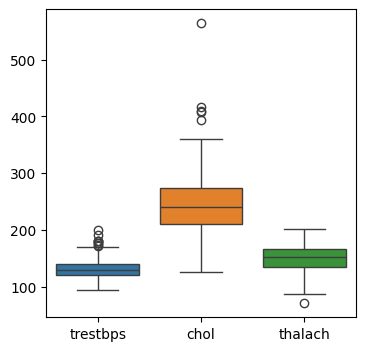

In [6]:
# Creating boxplot of numerical columns with missing values
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,4))
sns.boxplot(data=df[['trestbps','chol','thalach']])
plt.show()

In [7]:
# Fill missing values in all 3 columns by their respective median
df["trestbps"] = df["trestbps"].fillna(df["trestbps"].median())
df["chol"] = df["chol"].fillna(df["chol"].median())
df["thalach"] = df["thalach"].fillna(df["thalach"].median())
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
# Converting non numerical columns into numerical ones
df = pd.get_dummies(df, columns=["sex"], drop_first=True)
df

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no,False
299,45,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no,True
300,68,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no,True
301,57,0,130.0,131.0,0,1,115.0,1,1.2,1,1,3,no,True


In [9]:
# Checking categories of target column
df['target'].value_counts()
# Converting non numerical columns into numerical ones
df["target"] = df["target"].map({"yes": 1, "no": 0})
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,1,False


In [10]:
# Splitting X and y from df
X = df.drop("target", axis=1)
y = df["target"]

In [11]:
X

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,False
299,45,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,True
300,68,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,True
301,57,0,130.0,131.0,0,1,115.0,1,1.2,1,1,3,True


In [12]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [13]:
# Extracting train and test data from X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Feature Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [16]:
# Model Selection
models = {
"Logistic Regression": LogisticRegression(max_iter=1000),
"Naive Bayes": GaussianNB(),
"Decision Tree": DecisionTreeClassifier(random_state=42),
"Random Forest": RandomForestClassifier(random_state=42)
}

In [17]:
# Training and Testing all Models
results = {}
for name, model in models.items():
    print(f"\n===== {name} =====")
# Use scaled data only for Logistic Regression and Naive Bayes
    if name in ["Logistic Regression", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = [acc, pre, rec, f1]
    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall :", rec)
    print("F1 Score :", f1)
results_df = pd.DataFrame(results,index=["Accuracy", "Precision", "Recall", "F1 Score"]).T
results_df


===== Logistic Regression =====
Accuracy : 0.8524590163934426
Precision: 0.8709677419354839
Recall : 0.84375
F1 Score : 0.8571428571428571

===== Naive Bayes =====
Accuracy : 0.8688524590163934
Precision: 0.9
Recall : 0.84375
F1 Score : 0.8709677419354839

===== Decision Tree =====
Accuracy : 0.819672131147541
Precision: 0.8620689655172413
Recall : 0.78125
F1 Score : 0.819672131147541

===== Random Forest =====
Accuracy : 0.8360655737704918
Precision: 0.84375
Recall : 0.84375
F1 Score : 0.84375


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.852459,0.870968,0.84375,0.857143
Naive Bayes,0.868852,0.900000,0.84375,0.870968
Decision Tree,0.819672,0.862069,0.78125,0.819672
Random Forest,0.836066,0.843750,0.84375,0.843750


In [18]:
# Checking best ML model for the data
best_model_name = results_df["Recall"].idxmax()
print("Best model based on Recall:", best_model_name)
best_model = models[best_model_name]
if best_model_name in ["Logistic Regression", "Naive Bayes"]:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)
# Saving the model

with open("model.pkl","wb") as f:
    pickle.dump(best_model,f)
# Saving the scaler===
if best_model_name in ["Logistic Regression","Naive Bayes"]:
    with open("scaler.pkl","wb") as f:
        pickle.dump(scaler,f)

Best model based on Recall: Logistic Regression
